# PARCO for the HCVRP

Learning a Parallel AutoRegressive policy for a Combinatorial Optimization problem: the Heterogeneous Capacitated Vehicle Routing Problem (HCVRP).

<a href="https://colab.research.google.com/github/ai4co/parco/blob/main/examples/1.quickstart-hcvrp.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>  <a href="https://arxiv.org/abs/2409.0381"><img src="https://img.shields.io/badge/arXiv-2409.03811-b31b1b.svg" alt="Open In ArXiv"></a>


In [1]:
%load_ext autoreload
%autoreload 2

import torch
from rl4co.utils.trainer import RL4COTrainer

from parco.envs import HCVRPEnv
from parco.models import PARCORLModule, PARCOPolicy

# Greedy rollouts over trained model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

e:\Đồ án\parco\.venv\Lib\site-packages\torchrl\data\replay_buffers\samplers.py:37: UserWarning: Failed to import torchrl C++ binaries. Some modules (eg, prioritized replay buffers) may not work with your installation. This is likely due to a discrepancy between your package version and the PyTorch version. Make sure both are compatible. Usually, torchrl majors follow the pytorch majors within a few days around the release. For instance, TorchRL 0.5 requires PyTorch 2.4.0, and TorchRL 0.6 requires PyTorch 2.5.0.
  warnings.warn(EXTENSION_WARNING)
e:\Đồ án\parco\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Environment

In [2]:
env = HCVRPEnv(generator_params=dict(num_loc=60, num_agents=5),
               data_dir="",
               val_file="../data/hcvrp/n60_m5_seed24610.npz",
               test_file="../data/hcvrp/n60_m5_seed24610.npz",
               )            
td_test_data = env.generator(batch_size=[3])
td_init = env.reset(td_test_data.clone()).to(device)
td_init_test = td_init.clone()

## Model

Here we declare our policy and our PARCO model (policy + environment + RL algorithm)

In [3]:
emb_dim = 128

# Policy is the neural network
policy = PARCOPolicy(env_name=env.name,
                    embed_dim=emb_dim,
                    agent_handler="highprob",
                    normalization="rms",
                    context_embedding_kwargs={
                        "normalization": "rms",
                        "norm_after": False,
                        }, # these kwargs go to the context embed (communication layers)
                    norm_after=False, # True means we use Kool structure
                   )

# We refer to the model as the policy + the environment + training data (i.e. full RL algorithm)
model = PARCORLModule(      env, 
                            policy=policy,
                            train_data_size=1000,    # Small size for demo
                            val_data_size=100,       # Small size for demo
                            batch_size=64,              # Small size for demo
                            num_augment=8,              # SymNCO augments to use as baseline
                            train_min_agents=5,         # Minmum number of agents to train on
                            train_max_agents=5,        # Maximum number of agents to train on
                            train_min_size=60,          # Minimum number of locations to train on
                            train_max_size=60,         # Maximum number of locations to train on 
                            optimizer_kwargs={'lr': 1e-4, 'weight_decay': 0}, # Here we have a higher learning rate for demo
)    # example, fewer epochs and simpler model for demo

e:\Đồ án\parco\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
e:\Đồ án\parco\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.


### Test untrained model

Average tour length: 13.42
Tour 0 length: 13.89
Tour 1 length: 13.77
Tour 2 length: 12.58


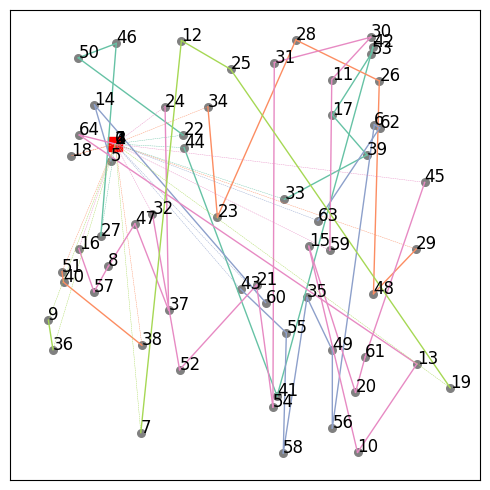

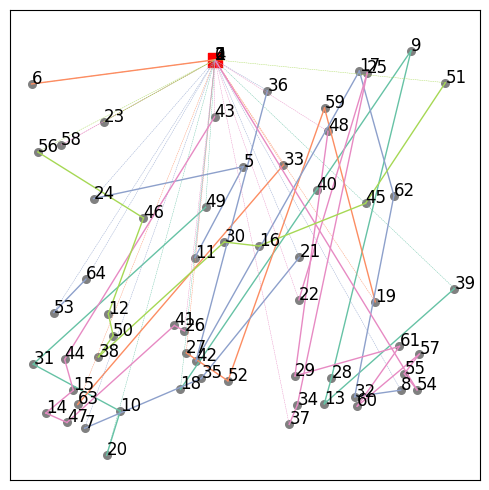

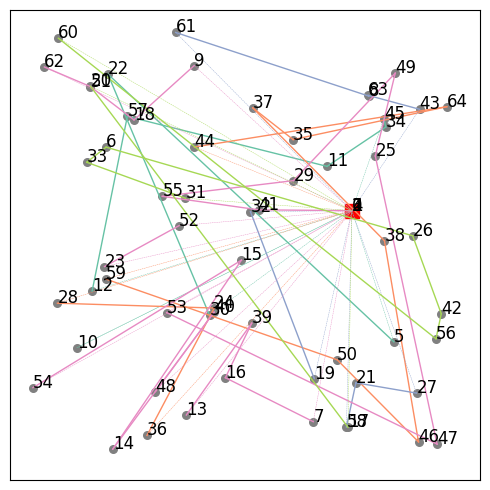

In [4]:
policy = model.policy.to(device)
out = policy(td_init_test.clone(), env, decode_type="greedy", return_actions=True)

# Plotting
actions = out["actions"]# .reshaape(td_init.shape[0], -1)
print("Average tour length: {:.2f}".format(-out['reward'].mean().item()))
for i in range(3):
    print(f"Tour {i} length: {-out['reward'][i].item():.2f}")
    env.render(td_init[i], actions[i].cpu(), plot_number=True)

## Training

In here we call the trainer and then fit the model

In [5]:
trainer = RL4COTrainer(
    max_epochs=5, # few epochs for demo
    accelerator="gpu", # change to cpu if you don't have a GPU (note: this will be slow!)
    devices=1, # change this to your GPU number
    logger=None,
)

Using 16bit Automatic Mixed Precision (AMP)
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
e:\Đồ án\parco\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [6]:
trainer.fit(model)

Provided file name ../data/hcvrp/n60_m5_seed24610.npz not found. Make sure to provide a file in the right path first or unset val_file to generate data automatically instead
Provided file name ../data/hcvrp/n60_m5_seed24610.npz not found. Make sure to provide a file in the right path first or unset test_file to generate data automatically instead
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type        | Params | Mode 
--------------------------------------------------------
0 | env             | HCVRPEnv    | 0      | train
1 | policy          | PARCOPolicy | 990 K  | train
2 | baseline        | NoBaseline  | 0      | train
3 | projection_head | MLP         | 33.0 K | train
--------------------------------------------------------
1.0 M     Trainable params
0         Non-trainable params
1.0 M     Total params
4.094     Total estimated model params size (MB)
91        Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

e:\Đồ án\parco\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
e:\Đồ án\parco\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
e:\Đồ án\parco\.venv\Lib\site-packages\torch\nn\functional.py:2954: UserWarning: Mismatch dtype between input and weight: input dtype = struct c10::Half, weight dtype = float, Cannot dispatch to fused implementation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\layer_norm.cpp:347.)
  return torch.rms_norm(input, normalized_shape, weight, eps)


e:\Đồ án\parco\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
e:\Đồ án\parco\.venv\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (16) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 4: 100%|██████████| 16/16 [00:07<00:00,  2.27it/s, v_num=0, train/reward=-10.4, train/loss=-0.0917, val/reward=-10.4]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 16/16 [00:07<00:00,  2.25it/s, v_num=0, train/reward=-10.4, train/loss=-0.0917, val/reward=-10.4]


## Evaluating the trained model

Now, we take the testing instances from above and evaluate the trained model on them with different evaluation techniques:
- Greedy: We take the action with the highest probability
- Sampling: We sample from the probability distribution N times and take the best one
- Augmentation: we first augment N times the state and then take the best action

### Greedy evaluation

Here we simply take the solution with greedy decoding type

Average tour length: 11.67
Tour 0 length: 8.62
Tour 1 length: 11.87
Tour 2 length: 14.52


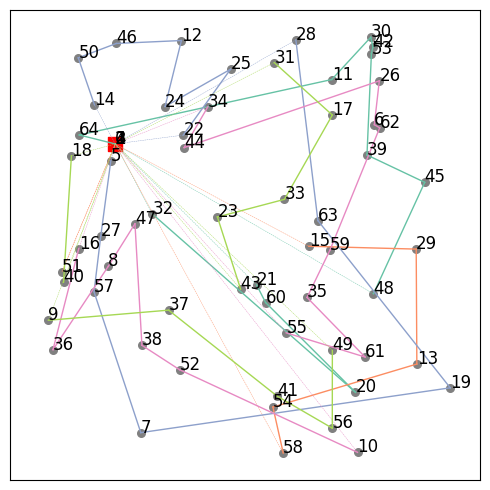

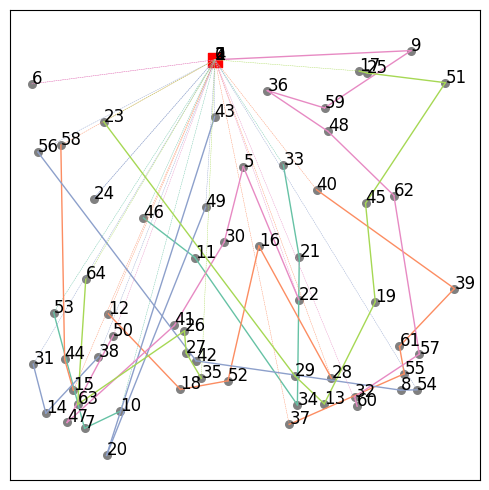

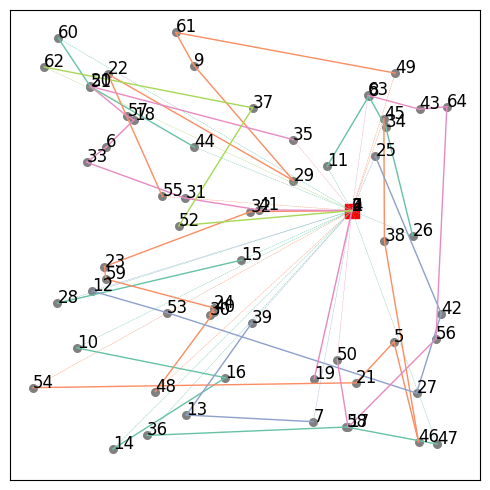

In [7]:
# Use same initial td as before
model = model.to(device)
out = model(td_init_test.clone(), phase="test", decode_type="greedy", return_actions=True)

# Plotting
actions =  out["actions"]#.reshape(td_init.shape[0], -1)
print("Average tour length: {:.2f}".format(-out['reward'].mean().item()))
for i in range(3):
    print(f"Tour {i} length: {-out['reward'][i].item():.2f}")
    env.render(td_init[i], actions[i].cpu(), plot_number=True)